# Etap 4 i 5: Podział danych, Walidacja i Modelowanie (Klasyfikacja)
W tym notatniku zajmiemy się przewidywaniem planów zawodowych ankietowanych (`CareerPlansThisYear`). Z powodu silnego niezbalansowania klas, zastosujemy stratyfikowany podział danych (Stratified Split), wagi klas (class_weight='balanced') oraz odpowiednie metryki oceny (F1-score, Confusion Matrix).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

# Load processed data
file_path = '../data/processed/processed_data.csv'
df = pd.read_csv(file_path)

# Identify the exact name of the target column
career_col = [col for col in df.columns if 'CareerPlans' in col][0]

# Encode target categorical variable into numerical labels
le = LabelEncoder()
df['Target_Encoded'] = le.fit_transform(df[career_col])

# Display the mapping of classes
print("Class mapping:")
for idx, class_name in enumerate(le.classes_):
    print(f"{idx}: {class_name}")
    
print(f"\nData loaded. Shape: {df.shape}")

Class mapping:
0: Change both employers and roles
1: Not Asked
2: Prefer not to say
3: Stay with the same employer,  but change roles
4: Stay with the same employer, same role
5: Stay with the same role, but change employers

Data loaded. Shape: (14755, 2953)


### Podział danych i walidacja dla zadania klasyfikacji

**Uzasadnienie wyboru parametrów:**
Dla zmiennej `CareerPlansThisYear` mamy do czynienia z drastycznym niezbalansowaniem klas. Z tego powodu:
1. Do podziału na zbiór treningowy i testowy (80/20) użyto parametru `stratify=y`, co gwarantuje zachowanie oryginalnych proporcji klas w obu zbiorach.
2. Zamiast standardowego K-Fold, zastosowano **Stratified K-Fold (k=5)**. Dzięki temu podczas walidacji krzyżowej każdy z 5 podzbiorów (foldów) będzie zawierał reprezentatywną próbkę nawet najrzadziej występujących odpowiedzi.

In [2]:
# 1. Define Target and Features
y = df['Target_Encoded']

# Drop target columns and the continuous target variables from regression phase
X = df.drop(columns=[career_col, 'Target_Encoded', 'SalaryUSD', 'SalaryUSD_Log'])

# 2. Stratified Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set: X={X_test.shape}, y={y_test.shape}")

# 3. Define Stratified K-Fold Cross Validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Cross-validation strategy defined: Stratified {skf.get_n_splits()}-Fold CV")

Training set: X=(11804, 2949), y=(11804,)
Testing set: X=(2951, 2949), y=(2951,)
Cross-validation strategy defined: Stratified 5-Fold CV


### 5. Budowa modeli uczenia maszynowego (Klasyfikacja)

W tej sekcji zbudujemy i przeanalizujemy trzy modele klasyfikacyjne dla zmiennej `CareerPlansThisYear` (zmapowanej jako `Target_Encoded`):
1. **Logistic Regression** (z parametrem `class_weight='balanced'`) jako model bazowy.
2. **Random Forest Classifier** (z parametrem `class_weight='balanced'`) jako zaawansowany model nieliniowy.
3. **LightGBM Classifier** z optymalizacją hiperparametrów metodą `RandomizedSearchCV`.

Główną metryką sukcesu jest **Macro F1-score**, ponieważ średnia dokładność (Accuracy) byłaby niemiarodajna przy tak dużym dysbalansie klas. Do wizualizacji błędów każdego modelu wykorzystamy macierz pomyłek (Confusion Matrix).

In [3]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

# Dictionary to store results for final classification comparison
classification_results = {}

def evaluate_classification_model(model_name, model, X_train, y_train, X_test, y_test, skf_obj):
    # Fit the model on training data
    model.fit(X_train, y_train)
    
    # Make predictions on test data
    preds = model.predict(X_test)
    
    # Calculate Macro F1-score
    f1_macro = f1_score(y_test, preds, average='macro')
    
    # Perform Stratified Cross-Validation on training data
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf_obj, scoring='f1_macro', n_jobs=-1)
    cv_f1_macro = cv_scores.mean()
    
    print(f"=== {model_name} ===")
    print(f"Cross-Validation Macro F1-score: {cv_f1_macro:.4f}")
    print("\nTest Classification Report:")
    print(classification_report(y_test, preds, target_names=le.classes_))
    print("=" * 40)
    
    # Save metrics to the global dictionary
    classification_results[model_name] = {
        'CV_F1_Macro': cv_f1_macro,
        'Test_F1_Macro': f1_macro
    }
    
    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    ax.set_title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()
    
    return model

Training Logistic Regression (Baseline)...
=== Logistic Regression ===
Cross-Validation Macro F1-score: 0.3448

Test Classification Report:
                                                precision    recall  f1-score   support

               Change both employers and roles       0.08      0.18      0.11       181
                                     Not Asked       1.00      1.00      1.00       576
                             Prefer not to say       0.09      0.17      0.12       192
Stay with the same employer,  but change roles       0.15      0.26      0.19       255
        Stay with the same employer, same role       0.68      0.36      0.47      1470
 Stay with the same role, but change employers       0.16      0.24      0.19       277

                                      accuracy                           0.44      2951
                                     macro avg       0.36      0.37      0.35      2951
                                  weighted avg       0.57      0.4

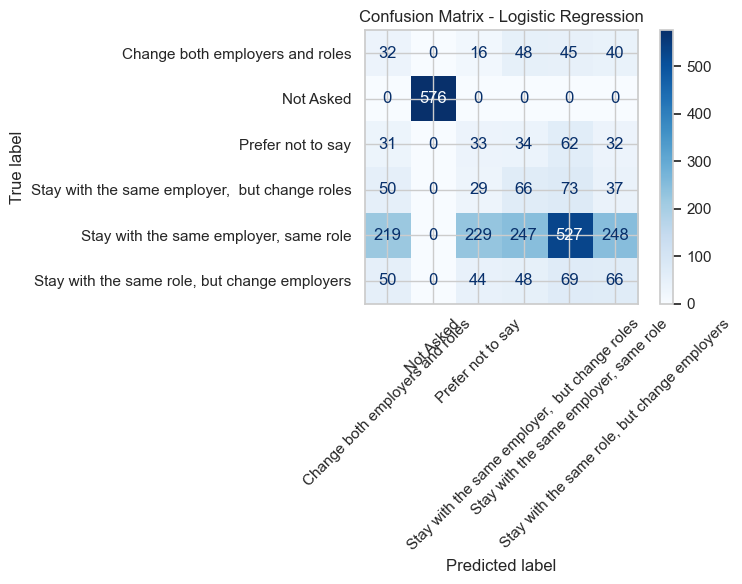

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [4]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression (Baseline)...")

# Initialize the model with balanced class weights to handle the severe imbalance
# max_iter is increased to 1000 to ensure convergence with high-dimensional data (2949 columns)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Evaluate the model using our custom classification function
evaluate_classification_model("Logistic Regression", log_reg, X_train, y_train, X_test, y_test, skf)

Training Random Forest Classifier (This might take a minute)...
=== Random Forest ===
Cross-Validation Macro F1-score: 0.3059

Test Classification Report:
                                                precision    recall  f1-score   support

               Change both employers and roles       0.67      0.02      0.04       181
                                     Not Asked       1.00      1.00      1.00       576
                             Prefer not to say       1.00      0.02      0.03       192
Stay with the same employer,  but change roles       0.00      0.00      0.00       255
        Stay with the same employer, same role       0.62      1.00      0.77      1470
 Stay with the same role, but change employers       0.33      0.00      0.01       277

                                      accuracy                           0.69      2951
                                     macro avg       0.60      0.34      0.31      2951
                                  weighted avg     

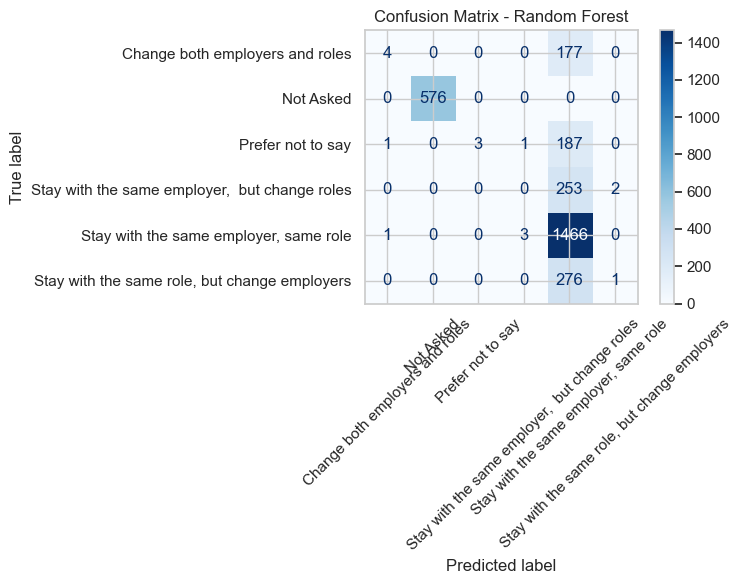

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Classifier (This might take a minute)...")

# Initialize the Random Forest model
# class_weight='balanced_subsample' computes weights based on the bootstrap sample for every tree grown
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced_subsample', 
    random_state=42, 
    n_jobs=-1
)

# Evaluate the model
evaluate_classification_model("Random Forest", rf_clf, X_train, y_train, X_test, y_test, skf)

In [6]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Starting Hyperparameter Tuning for LightGBM...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 777
[LightGBM] [Info] Number of data points in the train set: 11804, number of used features: 190
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Best LightGBM parameters found: {'num_leaves': 63, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.1}

[LightGBM] [Info] Auto-choos

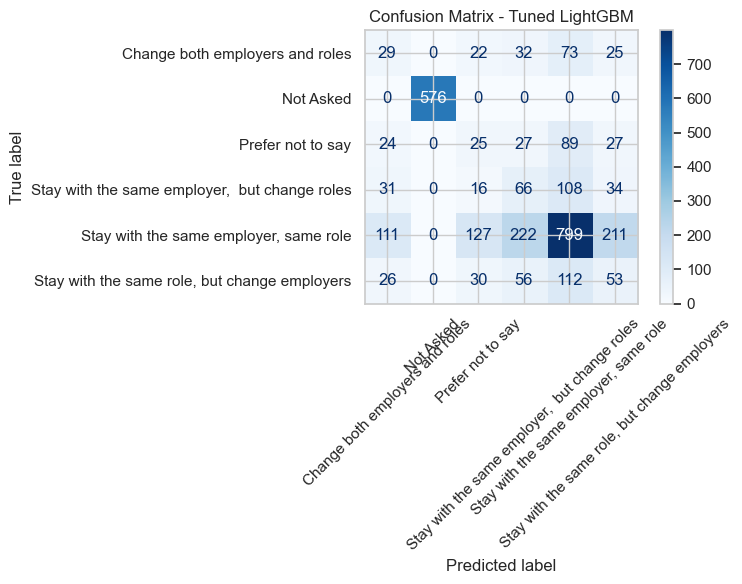

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [7]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import re

print("Starting Hyperparameter Tuning for LightGBM...")

# Helper function to clean and deduplicate column names for LightGBM
def clean_and_deduplicate_columns(columns):
    # 1. Replace all non-alphanumeric characters with '_'
    cleaned = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in columns]
    
    # 2. Remove duplicates by adding suffixes (_1, _2, etc.)
    seen = {}
    deduplicated = []
    for col in cleaned:
        if col not in seen:
            seen[col] = 1
            deduplicated.append(col)
        else:
            deduplicated.append(f"{col}_{seen[col]}")
            seen[col] += 1
    return deduplicated

# Apply the cleaning function to both train and test sets
X_train.columns = clean_and_deduplicate_columns(X_train.columns)
X_test.columns = clean_and_deduplicate_columns(X_test.columns)

# Initialize LightGBM with balanced class weights
lgbm_base = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Define parameter grid for tuning
param_grid_lgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 10, -1],
    'num_leaves': [31, 63, 127]
}

# Setup RandomizedSearchCV using our StratifiedKFold (skf)
lgb_random = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_grid_lgb,
    n_iter=5, # 5 random combinations for speed
    scoring='f1_macro',
    cv=skf, 
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model
lgb_random.fit(X_train, y_train)

print(f"\nBest LightGBM parameters found: {lgb_random.best_params_}\n")

# Evaluate the best version using our custom function
best_lgb = lgb_random.best_estimator_
evaluate_classification_model("Tuned LightGBM", best_lgb, X_train, y_train, X_test, y_test, skf)


--- Final Model Comparison (Macro F1-Score) ---


,CV_F1_Macro,Test_F1_Macro
Logistic Regression,0.344785,0.347031
Random Forest,0.305922,0.307738
Tuned LightGBM,0.365429,0.373016


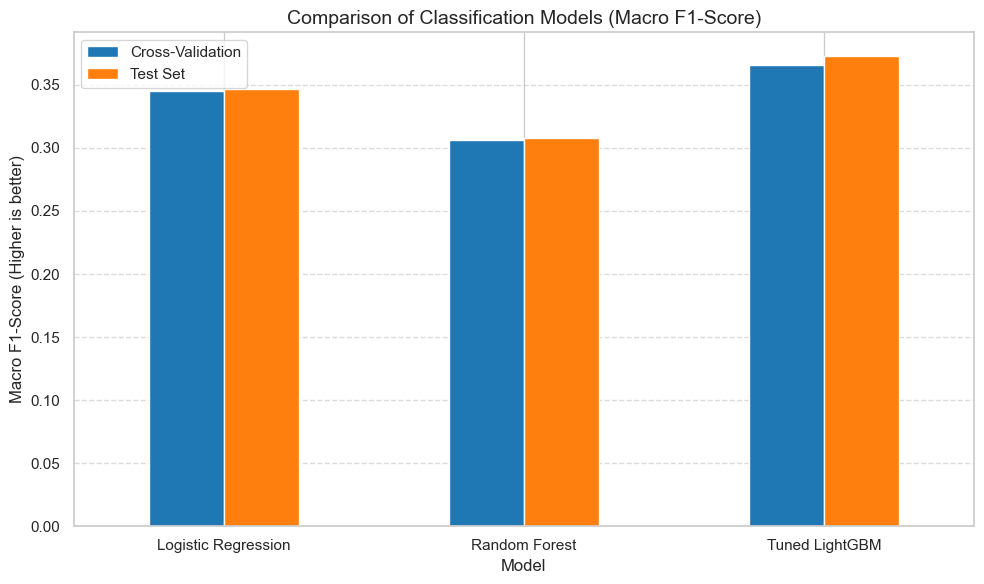

In [8]:
# Convert our results dictionary into a Pandas DataFrame
results_df = pd.DataFrame(classification_results).T

print("\n--- Final Model Comparison (Macro F1-Score) ---")
display(results_df)

# Plotting the comparison
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='bar', y=['CV_F1_Macro', 'Test_F1_Macro'], ax=ax, color=['#1f77b4', '#ff7f0e'])

plt.title('Comparison of Classification Models (Macro F1-Score)', fontsize=14)
plt.ylabel('Macro F1-Score (Higher is better)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Cross-Validation', 'Test Set'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot for the final PDF report
plt.savefig('../data/classification_comparison.png', dpi=300)
plt.show()

Generowanie Feature Importance dla modelu LightGBM...


C:\Users\n1107\AppData\Local\Temp\ipykernel_71372\4283023310.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_lgb_df, palette='magma')


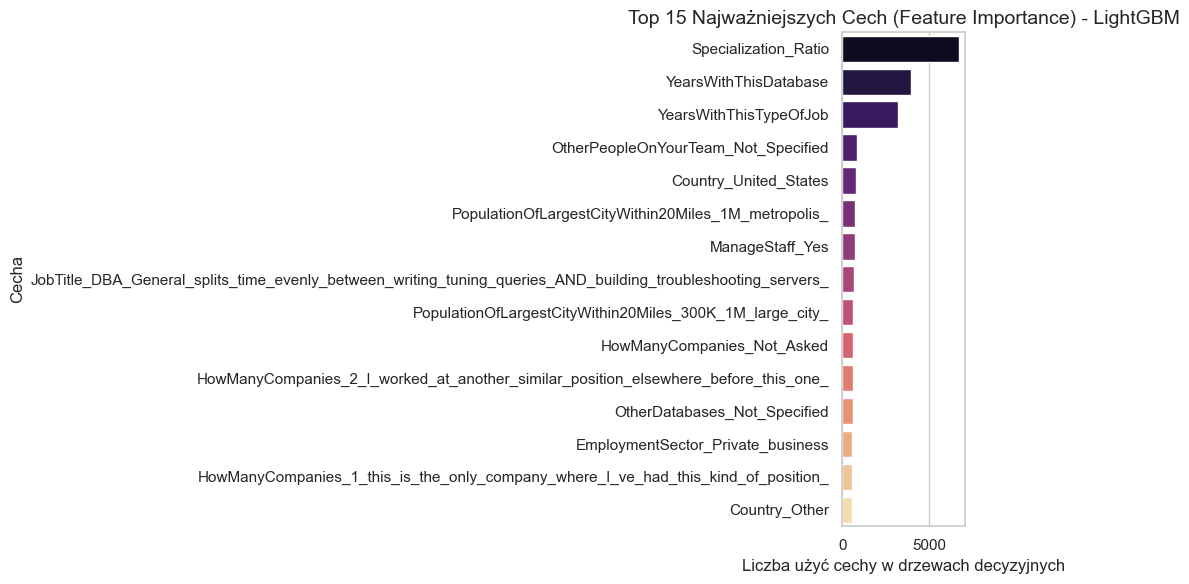

In [9]:

print("Generowanie Feature Importance dla modelu LightGBM...")

# Get feature importances (split type: number of times the feature is used in a model)
importances_lgb = best_lgb.feature_importances_
feature_names_lgb = X_train.columns

# Create a DataFrame and sort by importance
feat_imp_lgb_df = pd.DataFrame({
    'Feature': feature_names_lgb,
    'Importance': importances_lgb
}).sort_values(by='Importance', ascending=False).head(15) # Top 15 features

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_lgb_df, palette='magma')
plt.title('Top 15 Najważniejszych Cech (Feature Importance) - LightGBM', fontsize=14)
plt.xlabel('Liczba użyć cechy w drzewach decyzyjnych')
plt.ylabel('Cecha')
plt.tight_layout()
plt.savefig('../data/lgbm_feature_importance.png', dpi=300)
plt.show()